In [1]:
import matplotlib.pyplot as plt
import sisl
import numpy as np
from Zandpack.TimedependentTransport import TD_Transport
from Structures.Structures import Benzene_EU, Benzene_ED, Benzene_Dev
import matplotlib.image as img

dep:0: SislDeprecation: __init__ argument sc has been deprecated in favor of lattice, please update your code. [>=0.15] [removed in 0.16]
dep:0: SislDeprecation: __init__ argument sc has been deprecated in favor of lattice, please update your code. [>=0.15] [removed in 0.16]
warn:0: SislWarning: Lattice got initialized with one or more lattice vector(s) with 0 length. Use with care.
warn:0: SislWarning: Lattice got initialized with one or more lattice vector(s) with 0 length. Use with care.
dep:0: SislDeprecation: __init__ argument sc has been deprecated in favor of lattice, please update your code. [>=0.15] [removed in 0.16]


It is assumed that the following code will make sense given that last tutorials.

In [2]:
line = np.linspace(-2.5, 2.5, 100) + 1j * 1e-2     
line = np.vstack((line, line, 
                  line, line
                 ))                # Energy Sampling

C = sisl.Atom('C', R = 2.0)
H_idx = []
for i,a in enumerate(Benzene_Dev.atoms):
    if a.Z == 1:
        H_idx+= [i]
    else:
        Benzene_Dev.atoms[i] = C
for i,a in enumerate(Benzene_EU.atoms):
    Benzene_EU.atoms[i] = C
for i,a in enumerate(Benzene_ED.atoms):
    Benzene_ED.atoms[i] = C
BenD = Benzene_Dev.remove(H_idx)

In [3]:
EL = sisl.geom.sc(1.5, C).move([-2.5,15.7,0])
ER = sisl.geom.sc(1.5, C).move([+2.5,15.7,0])
EL.set_nsc((3,1,1))
EL = EL.add_vacuum(10,1).add_vacuum(10,2)
ER.set_nsc((3,1,1))
ER = ER.add_vacuum(10,1).add_vacuum(10,2)

Benzene_EU.set_nsc((1,3,1))
Benzene_ED.set_nsc((1,3,1))

BenD = BenD.add(EL).add(ER)
EL = EL.move(-EL.cell[0])
ER = ER.move(+ER.cell[0])
BenD = BenD.add(EL).add(ER)

H_Benzene_EU = sisl.Hamiltonian(Benzene_EU)
H_Benzene_ED = sisl.Hamiltonian(Benzene_ED)
HER          = sisl.Hamiltonian(ER)
HEL          = sisl.Hamiltonian(EL)

HEL.construct(          [[0.1, 2.0 ], [0.0, -0.5]])
HER.construct(          [[0.1, 2.0 ], [0.0, -0.5]])
H_Benzene_EU.construct( [[0.1, 2.0 ], [0.0, -1.0]])
H_Benzene_ED.construct( [[0.1, 2.0 ], [0.0, -1.0]])

Test = TD_Transport([Benzene_EU, 
                     Benzene_ED,
                     EL,ER
                    ], 
                     BenD, 
                     kT_i = [0.025, 0.025, 
                             0.025, 0.025
                            ],
                     mu_i = [0.0, 0.0, 
                             0.0, 0.0
                            ])

Test.Make_Contour(line, 18, pole_mode="JieHu2011")

In [5]:
Test.Electrodes(names = ['EU','ED', 
                         'EL', 'ER'
                        ],
                semi_infs=["+a2", "-a2", 
                           "-a1", "+a1"
                          ],kp = [[1,50,1], [1,50,1], 
                                  [50,1,1], [50,1,1]
                                 ] )
Test.make_device()
Dev = Test.Device.to_sisl()
Hdev = sisl.Hamiltonian(Dev)
Hdev.construct([[0.1, 2.25],[0.0, -1.0]])
Test.run_electrodes(manual_H = [H_Benzene_EU, H_Benzene_ED, HEL, HER])
Test.run_device(manual_H = Hdev)
Test.read_data()

[[12, 13, 14, 15], [16, 17, 18, 19], [26], [27]]
Running TB-Trans in Directory: Device!



dep:0: SislDeprecation: tbtncSileTBtrans.geom is deprecated, please use '.geometry'.0.14 [>=0.16]


Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)
Calculating corrections for electrode 2. (Normal electrode)
Calculating corrections for electrode 3. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!



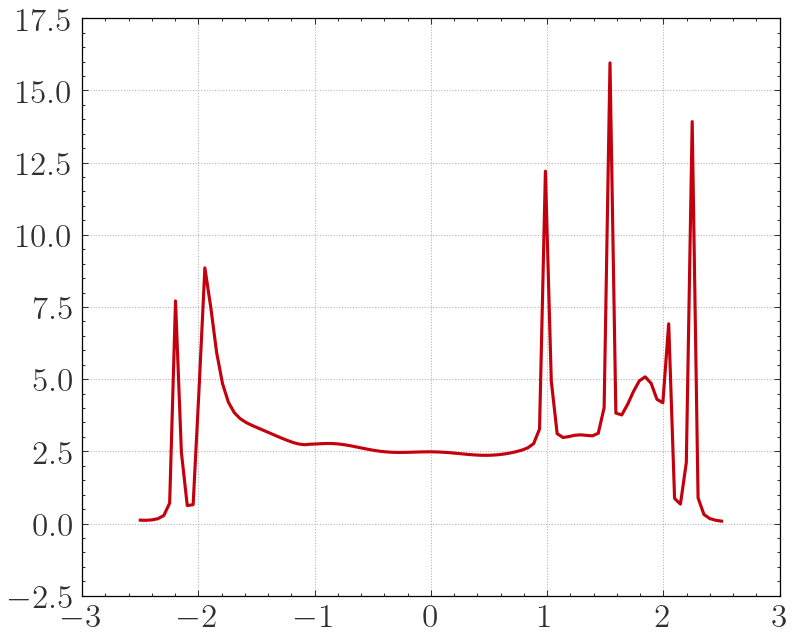

Normal plot


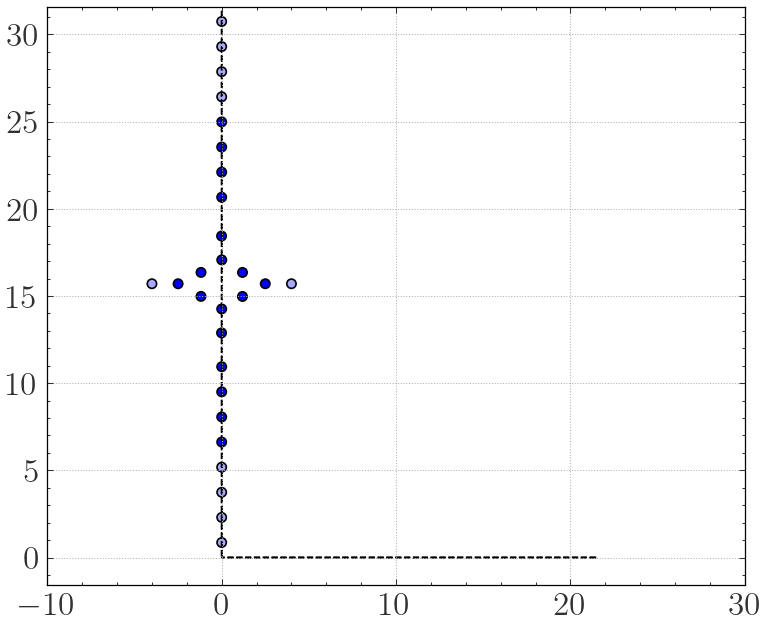

In [6]:
#Test.Inspect_Transmission(0,1)
tbt = sisl.get_sile('Device/siesta.TBT.nc')
plt.plot(tbt.E[Test.sampling_idx[0]], tbt.DOS()[Test.sampling_idx[0]])
plt.show()
Test.Device.Visualise()
#Test.Device.ase_visualise()

In [60]:
Test.reset_all_fits()
NL = 31
min_tol  = -0.0*np.ones(NL)
pdist, fact, pfact, cf = 0.1, 1.5, 1.2, 0.025
Emin, Emax = -2.5, 2.5
opts, fm= {'height':1.0, 'distance':5}, 'linear'
E1,G1=Test.PoleGuess(0,NL,Emin,Emax,fact=fact,cutoff=cf,
                  tol=.1,decimals=3,pole_dist=pdist,
                  pole_fact=pfact,opts=opts)
E2,G2=Test.PoleGuess(1,NL,Emin,Emax,fact=fact,cutoff=cf,
                  tol=.1,decimals=3,pole_dist=pdist,
                  pole_fact=pfact,opts=opts)
E3,G3=Test.PoleGuess(2,NL,Emin,Emax,fact=fact,cutoff=cf,
                  tol=.1,decimals=3,pole_dist=pdist,
                  pole_fact=pfact,opts=opts)
E4,G4=Test.PoleGuess(3,NL,Emin,Emax,fact=fact,cutoff=cf,
                  tol=.1,decimals=3,pole_dist=pdist,
                  pole_fact=pfact,opts=opts)
E1,E2,E3,E4 = E1[None,:], E2[None,:], E3[None,:], E4[None, :]
G1,G2,G3,G4 = G1[None,:], G2[None,:], G3[None,:], G4[None, :]
init_E = [E1, E2, E3, E4]
init_G = [G1, G2, G3, G4]

def run_mini(its):
    Test.Fit(fact = 0.05, 
             Fallback_W = 30.0, 
             NumL = NL,
             fit_mode      = 'all',
             force_PSD     = True,
             force_PSD_tol = [min_tol,]*4,
             use_analytical_jac = False,
             min_method = 'SLSQP',
             ebounds = (-2.5, 2.5),
             wbounds = (0.01, 1.5),
             gbounds = (None, None),
             options = {'disp':True,'maxiter':its, 
                        'gtol':1e-7,
                        'ftol':1e-7,
                        'iprint':1
                        },
             init_E   = init_E,                   # Give initial ei's and gi's
             init_G   = init_G,
             fit_real_part = False,
             specific_bounds = None,#[{(0 ,2) :[(0.1, 0.11), (4,5)]}, {(0 ,5) :[(-0.1, 0.1), (4,5)]}], 
             alpha_PO = 0.01, 
             )


(0,)
No poles identified... giving you a uniform grid...
---> Problem: Specifically, P had shape (0,) inside the PoleGuess function
(0,)
No poles identified... giving you a uniform grid...
---> Problem: Specifically, P had shape (0,) inside the PoleGuess function
(0,)
No poles identified... giving you a uniform grid...
---> Problem: Specifically, P had shape (0,) inside the PoleGuess function
(0,)
No poles identified... giving you a uniform grid...
---> Problem: Specifically, P had shape (0,) inside the PoleGuess function


In [61]:
run_mini(0)
Test.curvefit_all(0.00001)

Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 62
Iteration limit reached    (Exit mode 9)
            Current function value: 2.393178405467537
            Iterations: 1
            Function evaluations: 63
            Gradient evaluations: 1
Lorentzian fit took 0.04618072509765625 seconds.
Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 62
Iteration limit reached    (Exit mode 9)
            Current function value: 2.393178405467537
            Iterations: 1
            Function evaluations: 63
            Gradient evaluations: 1
Lorentzian fit took 0.04401850700378418 seconds.
Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

3
#Variables optimized for: 62
Iteration limit reached    (Exit mode 9)
            Current function value: 2.629187268307582
     

100%|████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 453.24it/s]


[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


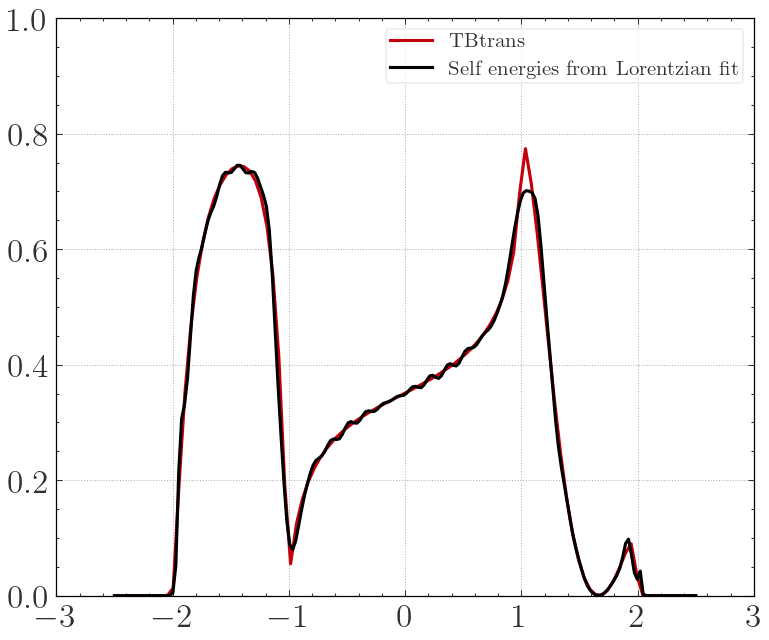

In [62]:
lead = 2
print(Test.fitted_lorentzians[lead].is_zero)
#Test.Inspect_Lorentzian_fit(lead, 6,6, 2,2, center_lines = True)
plt.show()
Test.Inspect_transmission_from_hilbert_transform(E=np.linspace(-2.5,2.5,200),eta=1e-2)

In [63]:
Test.tofile('4E')

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 1.779205
Minimum of eigenvalues of Lorentzian Gammas: 0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/TimedependentTransport.py:1159: RuntimeWarning: overflow encountered in exp
  f   = 1/(1 + np.exp((e - mu_dev)/kT_dev))


In [66]:
!SCF Dir=$PWD file=4E
!psinought Dir=$PWD file=4E
!mpirun -np 5 --oversubscribe zand Dir=$PWD




    ▂▃▅▆▇█ S █ C █ F █(v. 1.0)█▇▆▅▃▂
    
    (self-consistent field solver)
    Implements the TranSIESTA method with adaptive bias window integration.
    An orthogonal basis is assumed and is implemented in largely in NumPy.
        See Papior, Nick, et al. (2017) and Refs. therein
    
SCF Program Start

sys.argv: ['/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/cmdtools/SCF', 'Dir=/home/investigator/Desktop/TD_stuff/nb_tutorial/TightBinding/T4_N_elec', 'file=4E']

{'Contour': 'None', 'kT': '0.025', 'file': '4E', 'kweights': 'kweights.npy', 'drho_tol': '1e-5', 'history': '6', 'weight': '0.2', 'DM_start_file': 'None', 'nprocs': '1', 'backend': 'loky', 'DM_out_file': 'None', 'UfUd': 'False', 'real_line_integral': 'False', 'real_line_min': '-60.', 'real_line_max': '20.0', 'real_line_N': '20', 'real_line_exact_fermi': 'False', 'Nonequilibrium': 'False', 'DM_randomness': '0.001', 'random_on_diag_only': 'True', 'memory_conserve': 'False', 'fact_kT': '10.0', 'tolerance':

td_info Program Start

sys.argv: ['/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/cmdtools/td_info', 'Dir=/home/investigator/Desktop/TD_stuff/nb_tutorial/TightBinding/T4_N_elec', 'file=4E', 'plotcurrent=1', 'label=Current', 'format=png']

[0]
Figure(900x750)


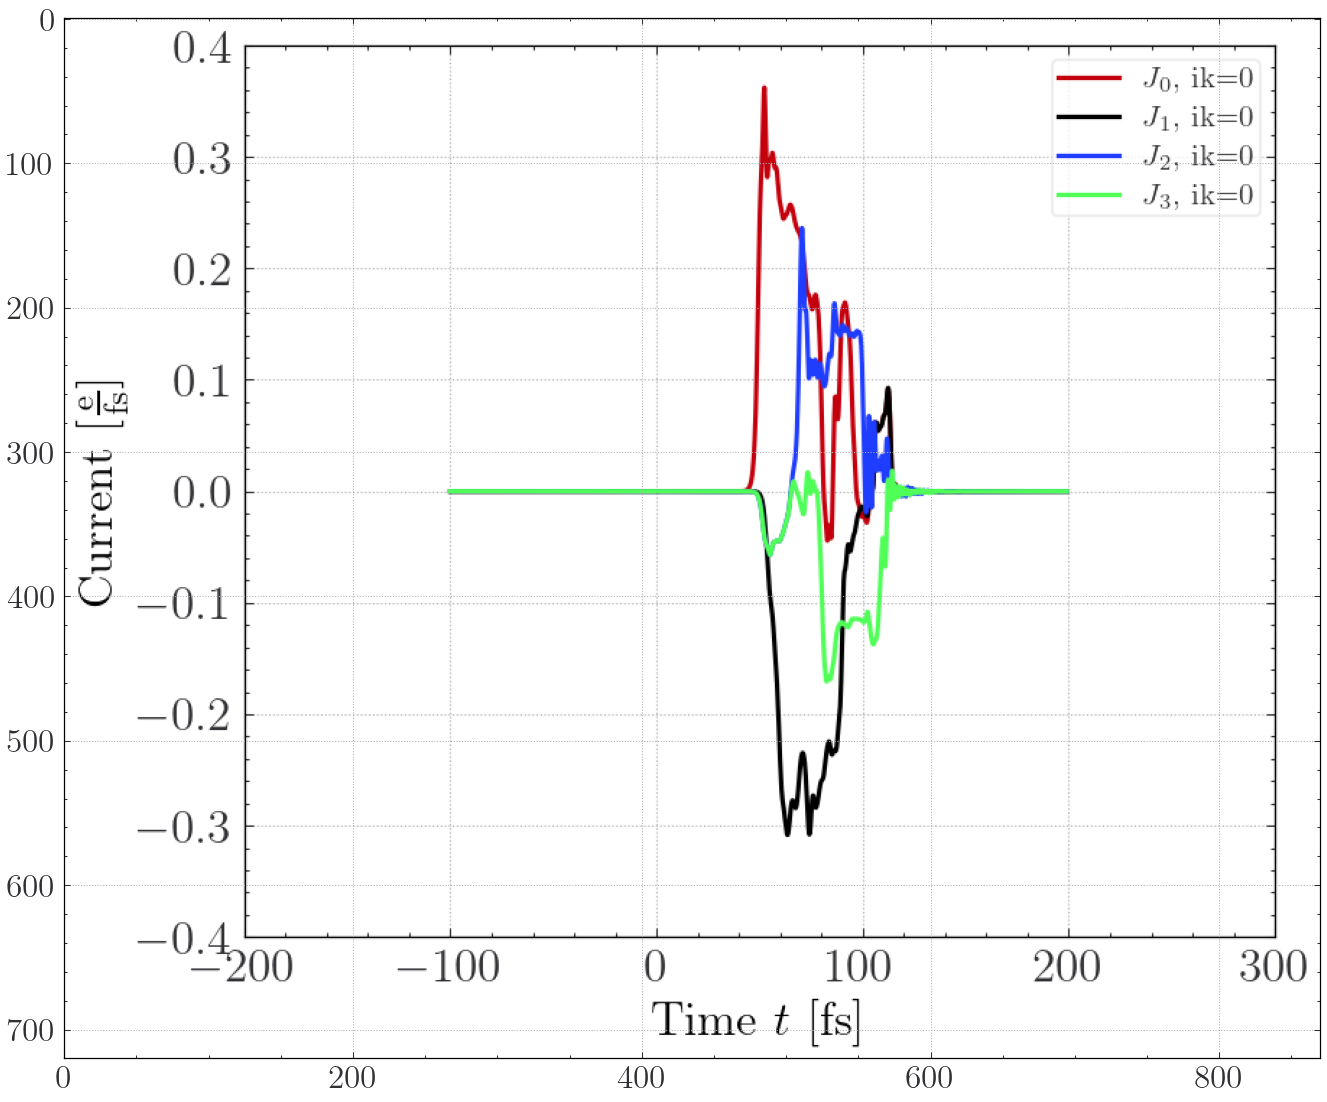

In [67]:
!td_info Dir=$PWD file=4E plotcurrent=1 label=Current format=png
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(15,9)
plt.imshow(im)

In [71]:
import sparse as sp
no = Test.Hdense.shape[-1]

v_mnpq = sp.DOK((no,no,no,no))
X  = Test.Device.pos_real_space[Test.pivot] 
prefactor = 0.5#14.39 # eV * Å

for m in range(no):
    for n in range(no):
        for p in range(no):
            for q in range(no):
                if m!=n and n == p and m==q:
                    dij = np.linalg.norm(X[m] - X[n])
                    v_mnpq[m,n,p,q] = prefactor/dij
                    
v_mnpq = v_mnpq.to_coo()
amp = 1 / 4
w1,w2,w3,w4 = 0.5, 0.5, 0.5, 0.5
p1,p2,p3,p4 = 0.0, np.pi/2, np.pi, 3/2*np.pi
def dH(t, sig):
    out = np.zeros(sig.shape, dtype = np.complex128)
    dsig = sig# - sig0
    out[0] += 2 * ( v_mnpq * dsig[0][None, :, :, None]).sum(axis = (1,2)).todense()
    out[0] -= 1 * ( v_mnpq * dsig[0][None, :, None, :]).sum(axis = (1,3)).todense()
    return out

def env(t,t0):
    return 1-1/(1 + np.exp((t - t0)))

def ramp(t,t0):
    return 1+t/50

def delta(t, a):
    if   a == 0:
        return   amp*env(t, 10)*np.sin(w1 * t*ramp(t,10) + p1)
    elif a == 1:
        return   amp*env(t, 10)*np.sin(w2 * t*ramp(t,10) + p2)
    elif a == 2:
        return   amp*env(t, 10)*np.sin(w3 * t*ramp(t,10) + p3)
    elif a == 3:
        return   amp*env(t, 10)*np.sin(w4 * t*ramp(t,10) + p4)


In [72]:
v_mnpq.max()

0.3635461609017992

In [50]:
t, d = RK4(f,
           sig0,psi0, omg0,
           1e-9,    0.0,50.0,
           dH,z_delta, 
           Test.Ixi, name = 'Mol',
           elec_names = ['EU', 'ED', 'EL', 'ER'])
sig0_2 = np.load('Mol_last_sig.npy')
psi0_2 = np.load('Mol_last_psi.npy')
omg0_2 = np.load('Mol_last_omega.npy')


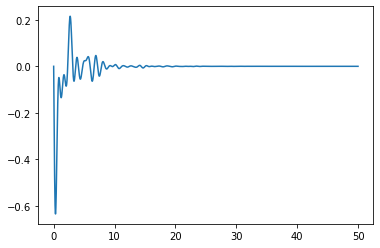

In [54]:
plt.plot(t, d['current_ER'])

In [27]:
t, d = RK4(f,
           sig0_2,psi0_2, omg0_2,
           1e-9,    0.0,100.0,
           dH,delta, 
           Test.Ixi, name = 'Mol',
           elec_names = ['EU', 'ED', 'EL', 'ER'])

(0.0, 80.0)

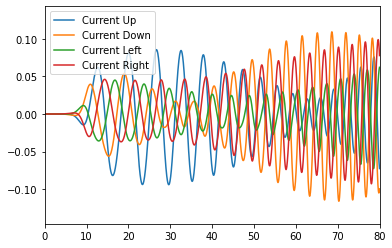

In [28]:
#Test.Inspect_transmission_from_hilbert_transform(eta = 1e-2); plt.ylim([-0.2, 5])
plt.plot(t, d['current_EU'],label = 'Current Up')
plt.plot(t, d['current_ED'],label = 'Current Down')
plt.plot(t, d['current_EL'],label = 'Current Left')
plt.plot(t, d['current_ER'],label = 'Current Right')
plt.legend()

plt.xlim([0,80])

#from siesta_python.funcs import diff_central
#N = np.trace(d['density matrix'],axis1 = 2, axis2 = 3)

#plt.plot(t,np.array(d['current_EU']) + np.array(d['current_ED'])+ np.array(d['current_ER']) + np.array(d['current_EL']))
#plt.show()
#plt.plot(t,N)

(7.731611269326793-3.0535988906951797e-16j)

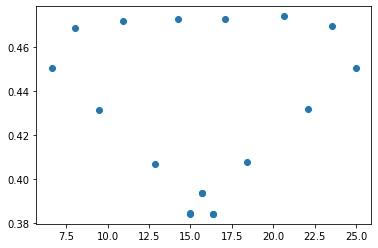

In [ ]:
from siesta_python.funcs import interpolate_and_fft

In [ ]:
N = np.array(d['density matrix'])
N = np.trace(N, axis1 = 2, axis2 = 3)
idx = t>0

ft,w = interpolate_and_fft(t[idx], N[idx,0], 10000)

In [ ]:
plt.plot(w, np.abs(ft)/5000)
plt.ylim([0,10])
plt.xlim([0,0.5])

In [ ]:
plt.plot(t,N)

In [ ]:
tbt = sisl.get_sile('Device/siesta.TBT.nc')
xyz = Test.Device.pos_real_space[tbt.pivot()]

In [ ]:
xyz.shape

In [ ]:
dm = d['density matrix'][:,0,:,:]

In [ ]:
dm.shape

In [ ]:
from scipy.interpolate import interp1d


In [ ]:
help(interp1d)

In [ ]:
T = np.linspace(t.min(), t.max(),120)
DMi = interp1d(t, dm.transpose(1,2,0))

In [ ]:
DM = DMi(T).transpose(2,0,1)

In [ ]:
DM.shape

In [ ]:
for i in range(len(T)):
    ti = T[i]
    S = np.diag(DM[i])
    plt.scatter(xyz[:,0], xyz[:,1], s = 300*(np.abs(S) - 0.4))
    plt.ylim([12,19])
    plt.xlim([-5,5])
    plt.axis('equal')
    plt.title('piece '+ str(i))
    plt.savefig('Savefigs/'+str(i),dpi = 100)
    plt.show()

In [ ]:
xyz.shape

In [ ]:
S.shape

In [ ]:
plt.plot(T, DM[:,5,5])

In [ ]:
y = 300*(np.abs(S) - 0.3)

In [ ]:
y